---
title: "Tugas Keandalan Kapal"
author: "Lintang Al Hilal Fitri — NRP 6018252006"
date: today
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from scipy.integrate import quad
import pandas as pd

BG='#ffffff'; GRID='#e0e0e0'; SPINE='#c0c0c0'
TEXT='#24292f'; SUBTEXT='#57606a'
COLORS={'vert':'#0969da','lat':'#cf222e','tors':'#1a7f37'}

## 1. Spektra Gelombang dan RAO

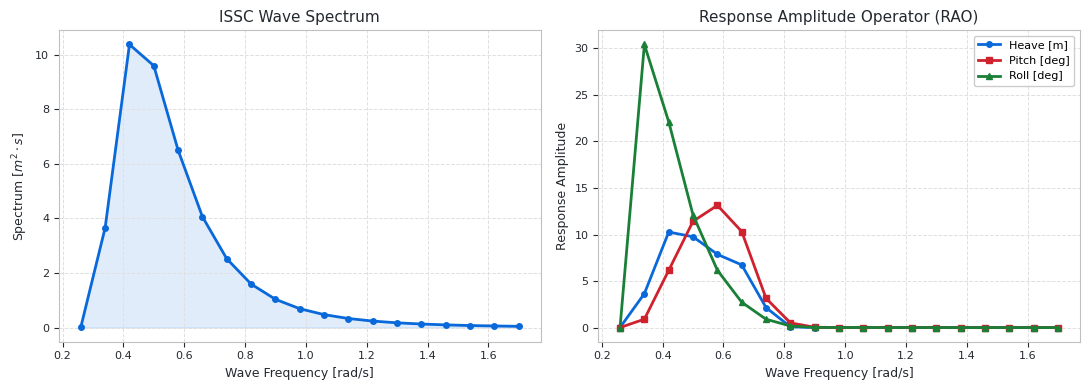

In [ ]:
wave_freq = np.array([0.26,0.34,0.42,0.50,0.58,0.66,0.74,
    0.82,0.90,0.98,1.06,1.14,1.22,1.30,1.38,1.46,1.54,1.62,1.70])
issc = np.array([0.012,3.654,10.376,9.598,6.500,4.060,2.520,
    1.594,1.035,0.691,0.474,0.332,0.238,0.174,0.130,
    0.098,0.075,0.059,0.046])
heave = np.array([0.012,3.648,10.263,9.757,7.867,6.734,2.146,
    0.080,0.005,0.006,0.001,0,0,0,0,0,0,0,0])
pitch = np.array([0.001,0.904,6.148,11.418,13.135,10.321,3.140,
    0.502,0.038,0.005,0.004,0.001,0,0,0,0,0,0,0])
roll  = np.array([0.005,30.419,22.114,12.086,6.159,2.724,0.894,
    0.171,0.011,0.007,0.007,0.002,0,0,0,0,0,0,0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(BG)
ax.plot(wave_freq, issc, color='#0969da', lw=2, marker='o', ms=4)
ax.fill_between(wave_freq, issc, color='#0969da', alpha=0.12)
ax.grid(True, ls='--', lw=0.7, color=GRID)
for s in ax.spines.values(): s.set_color(SPINE)
ax.tick_params(colors=TEXT, labelsize=8)
ax.set_title('ISSC Wave Spectrum', fontsize=11, color=TEXT)
ax.set_xlabel('Wave Frequency [rad/s]', fontsize=9, color=TEXT)
ax.set_ylabel(r'Spectrum [$m^2 \cdot s$]', fontsize=9, color=TEXT)

ax = axes[1]
ax.set_facecolor(BG)
ax.plot(wave_freq,heave,marker='o',ms=4,lw=2,color=COLORS['vert'],label='Heave [m]')
ax.plot(wave_freq,pitch,marker='s',ms=4,lw=2,color=COLORS['lat'],label='Pitch [deg]')
ax.plot(wave_freq,roll, marker='^',ms=4,lw=2,color=COLORS['tors'],label='Roll [deg]')
ax.grid(True,ls='--',lw=0.7,color=GRID)
for s in ax.spines.values(): s.set_color(SPINE)
ax.tick_params(colors=TEXT,labelsize=8)
ax.set_title('Response Amplitude Operator (RAO)',fontsize=11,color=TEXT)
ax.set_xlabel('Wave Frequency [rad/s]',fontsize=9,color=TEXT)
ax.set_ylabel('Response Amplitude',fontsize=9,color=TEXT)
ax.legend(fontsize=8,edgecolor=SPINE,facecolor=BG)
plt.tight_layout(); plt.show()

## 2. Momen Kapal

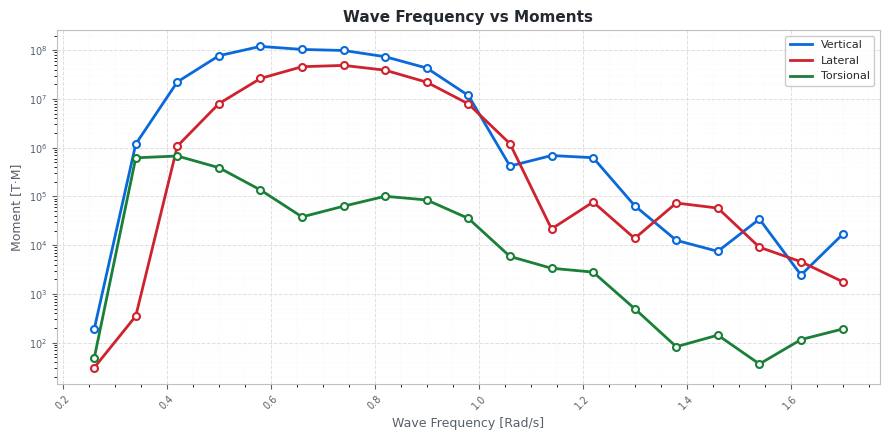

In [ ]:
frequency   = [0.26,0.34,0.42,0.50,0.58,0.66,0.74,0.82,0.90,
               0.98,1.06,1.14,1.22,1.30,1.38,1.46,1.54,1.62,1.70]
vert_moment = [1.88e+02,1.19e+06,2.24e+07,7.73e+07,1.20e+08,
               1.04e+08,9.89e+07,7.37e+07,4.31e+07,1.18e+07,4.21e+05,
               6.92e+05,6.25e+05,6.48e+04,1.26e+04,7.50e+03,3.44e+04,
               2.45e+03,1.67e+04]
lat_moment  = [3.07e+01,3.52e+02,1.08e+06,8.03e+06,2.64e+07,
               4.60e+07,4.89e+07,3.90e+07,2.21e+07,7.94e+06,1.21e+06,
               2.16e+04,7.70e+04,1.38e+04,7.35e+04,5.78e+04,9.10e+03,
               4.58e+03,1.79e+03]
tors_moment = [4.78e+01,6.21e+05,6.77e+05,3.90e+05,1.36e+05,
               3.81e+04,6.33e+04,1.01e+05,8.48e+04,3.55e+04,5.89e+03,
               3.37e+03,2.81e+03,4.99e+02,8.28e+01,1.43e+02,3.66e+01,
               1.16e+02,1.91e+02]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.grid(which='major',color=GRID,lw=0.7,ls='--',zorder=0)
ax.grid(which='minor',color='#f0f0f0',lw=0.3,ls=':',zorder=0)
ax.minorticks_on()
for data,label,color in [(vert_moment,'Vertical',COLORS['vert']),
    (lat_moment,'Lateral',COLORS['lat']),(tors_moment,'Torsional',COLORS['tors'])]:
    ax.plot(frequency,data,color=color,lw=2,label=label,zorder=2)
    ax.scatter(frequency,data,s=25,color='white',edgecolors=color,lw=1.5,zorder=3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.set_xlabel('Wave Frequency [Rad/s]',fontsize=9,color=SUBTEXT)
ax.set_ylabel('Moment [T·M]',fontsize=9,color=SUBTEXT)
ax.set_title('Wave Frequency vs Moments',fontsize=11,fontweight='bold',color=TEXT)
ax.tick_params(axis='x',rotation=45,labelsize=7,colors=SUBTEXT)
ax.tick_params(axis='y',labelsize=7,colors=SUBTEXT)
for s in ax.spines.values(): s.set_edgecolor(SPINE)
ax.legend(fontsize=8,edgecolor=SPINE,facecolor=BG,labelcolor=TEXT)
plt.tight_layout(); plt.show()

## 2.5 Mean dan Standar Deviasi Momen

In [ ]:
mu_vm  = np.mean(vert_moment);  std_vm  = np.std(vert_moment,  ddof=1)
mu_lm  = np.mean(lat_moment);   std_lm  = np.std(lat_moment,   ddof=1)
mu_tm  = np.mean(tors_moment);  std_tm  = np.std(tors_moment,  ddof=1)

df_moment_stats = pd.DataFrame({
    'Moment Type': ['Vertical','Lateral','Torsional'],
    'Mean [T·M]':  [f'{mu_vm:.4e}', f'{mu_lm:.4e}', f'{mu_tm:.4e}'],
    'Std Dev [T·M]':[f'{std_vm:.4e}',f'{std_lm:.4e}',f'{std_tm:.4e}']
})
print(df_moment_stats.to_string(index=False))

Moment Type Mean [T·M] Std Dev [T·M]
   Vertical 2.9172e+07    4.2646e+07
    Lateral 1.0575e+07    1.7028e+07
  Torsional 1.1368e+05    2.0992e+05


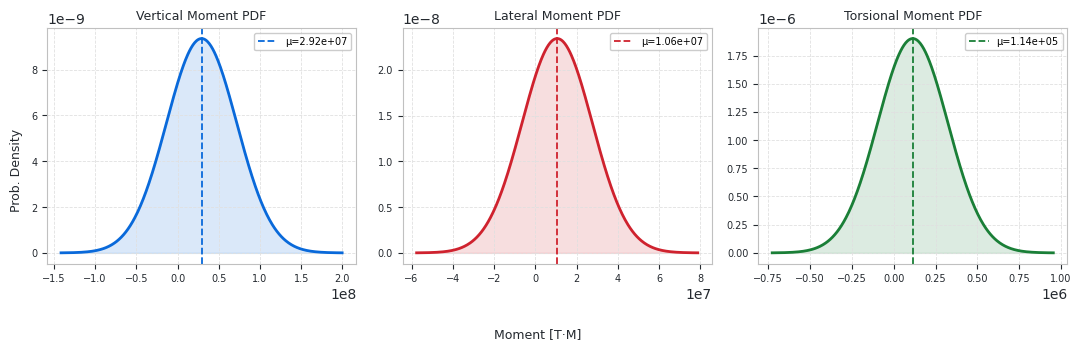

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
fig.patch.set_facecolor(BG)
pairs = [('Vertical',   mu_vm, std_vm, COLORS['vert']),
         ('Lateral',    mu_lm, std_lm, COLORS['lat']),
         ('Torsional',  mu_tm, std_tm, COLORS['tors'])]
for ax,(title,mu,std,color) in zip(axes, pairs):
    ax.set_facecolor(BG)
    x = np.linspace(mu - 4*std, mu + 4*std, 500)
    ax.plot(x, norm.pdf(x,mu,std), color=color, lw=2)
    ax.fill_between(x, norm.pdf(x,mu,std), color=color, alpha=0.15)
    ax.axvline(mu, color=color, ls='--', lw=1.3, label=f'μ={mu:.2e}')
    ax.grid(True,ls='--',lw=0.6,color=GRID)
    for s in ax.spines.values(): s.set_color(SPINE)
    ax.tick_params(colors=TEXT,labelsize=7)
    ax.set_title(f'{title} Moment PDF',fontsize=9,color=TEXT)
    ax.legend(fontsize=7,edgecolor=SPINE,facecolor=BG)
fig.supxlabel('Moment [T·M]',fontsize=9,color=TEXT)
fig.supylabel('Prob. Density',fontsize=9,color=TEXT)
plt.tight_layout(); plt.show()

## 3. Kekuatan Kapal (Yield Strength)

$\frac{1}{4} \text{inch ABS C Steel}$

Diketahui: $\mu = 35000\ \text{psi}$, $\text{COV} = 0.0069$, $\sigma = \mu \times \text{COV}$

Sumber: _An Introduction to Structural Reliability Theory_ (1990) SSC-351 

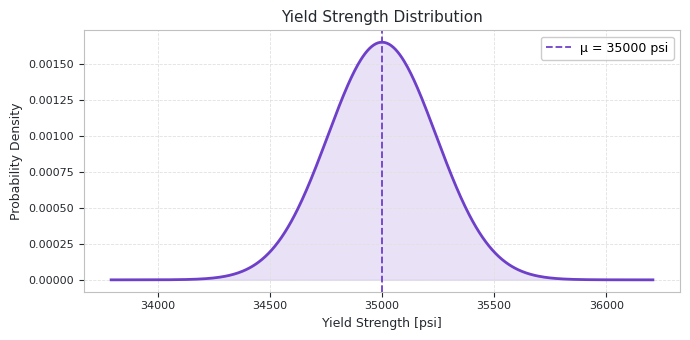

μ_strength  = 35000.0 psi
COV         = 0.0069
σ_strength  = 241.50 psi


In [ ]:
mu_strength_psi  = 35000.0
cov_strength     = 0.0069
std_strength_psi = mu_strength_psi * cov_strength

x_str = np.linspace(mu_strength_psi - 5*std_strength_psi,
                    mu_strength_psi + 5*std_strength_psi, 500)

fig, ax = plt.subplots(figsize=(7, 3.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.plot(x_str, norm.pdf(x_str, mu_strength_psi, std_strength_psi),
        color='#6e40c9', lw=2)
ax.fill_between(x_str, norm.pdf(x_str, mu_strength_psi, std_strength_psi),
                color='#6e40c9', alpha=0.15)
ax.axvline(mu_strength_psi, color='#6e40c9', ls='--', lw=1.3,
           label=f'μ = {mu_strength_psi:.0f} psi')
ax.grid(True,ls='--',lw=0.6,color=GRID)
for s in ax.spines.values(): s.set_color(SPINE)
ax.tick_params(colors=TEXT,labelsize=8)
ax.set_title('Yield Strength Distribution',fontsize=11,color=TEXT)
ax.set_xlabel('Yield Strength [psi]',fontsize=9,color=TEXT)
ax.set_ylabel('Probability Density',fontsize=9,color=TEXT)
ax.legend(fontsize=9,edgecolor=SPINE,facecolor=BG)
plt.tight_layout(); plt.show()

print(f"μ_strength  = {mu_strength_psi:.1f} psi")
print(f"COV         = {cov_strength}")
print(f"σ_strength  = {std_strength_psi:.2f} psi")

## 4. Konversi Yield Strength ke Yield Moment [T·M]

$M_{\text{tf·m}} \approx 703 \times \sigma_y[\text{psi}] \times Z[\text{m}^3]$

Modulus: Vertikal $Z_v=12000\ \text{m}^3$, Lateral $Z_l=1000\ \text{m}^3$, Torsional $Z_t=10\ \text{m}^3$

In [ ]:
Zv, Zl, Zt = 12000, 1000, 10          # m³
CONV_PSI_TFM = 6894.76 / 9806.65    # psi·m³ → tf·m  (≈ 0.7031)

# Mean yield moments
mu_Sv  = mu_strength_psi  * CONV_PSI_TFM * Zv
mu_Sl  = mu_strength_psi  * CONV_PSI_TFM * Zl
mu_St  = mu_strength_psi  * CONV_PSI_TFM * Zt

# Std yield moments (COV same as strength)
# std_Sv = std_strength_psi * CONV_PSI_TFM * Zv
# std_Sl = std_strength_psi * CONV_PSI_TFM * Zl
# std_St = std_strength_psi * CONV_PSI_TFM * Zt

std_Sv = mu_Sv * 0.069
std_Sl = mu_Sl * 0.069
std_St = mu_St * 0.069

df_strength = pd.DataFrame({
    'Type':            ['Vertical', 'Lateral', 'Torsional'],
    'Z [m³]':          [Zv, Zl, Zt],
    'μ_yield [T·M]':   [f'{mu_Sv:.2e}', f'{mu_Sl:.2e}', f'{mu_St:.2e}'],
    'σ_yield [T·M]':   [f'{std_Sv:.2e}', f'{std_Sl:.2e}', f'{std_St:.2e}'],
    'COV':             [f'{cov_strength}'] * 3
})
print(df_strength.to_string(index=False))

     Type  Z [m³] μ_yield [T·M] σ_yield [T·M]    COV
 Vertical   12000      2.95e+08      2.04e+07 0.0069
  Lateral    1000      2.46e+07      1.70e+06 0.0069
Torsional      10      2.46e+05      1.70e+04 0.0069


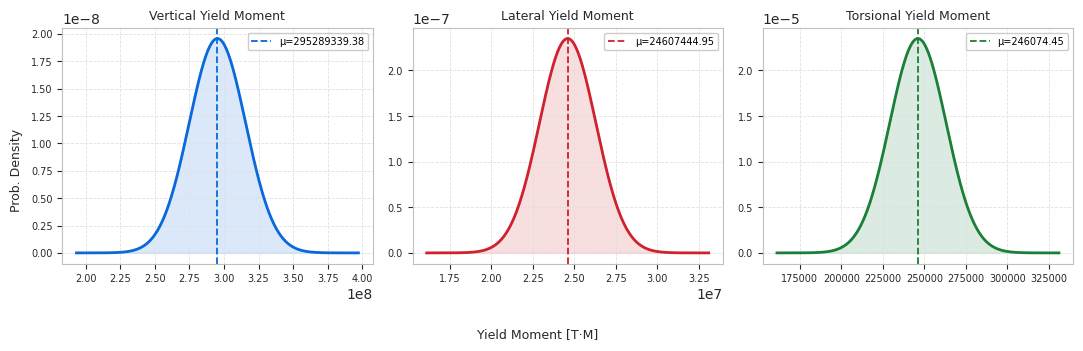

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
fig.patch.set_facecolor(BG)
pairs_s = [('Vertical Yield Moment',  mu_Sv, std_Sv, COLORS['vert']),
           ('Lateral Yield Moment',   mu_Sl, std_Sl, COLORS['lat']),
           ('Torsional Yield Moment', mu_St, std_St, COLORS['tors'])]
for ax,(title,mu,std,color) in zip(axes, pairs_s):
    ax.set_facecolor(BG)
    x = np.linspace(mu - 5*std, mu + 5*std, 500)
    ax.plot(x, norm.pdf(x,mu,std), color=color, lw=2)
    ax.fill_between(x, norm.pdf(x,mu,std), color=color, alpha=0.15)
    ax.axvline(mu, color=color, ls='--', lw=1.3, label=f'μ={mu:.2f}')
    ax.grid(True,ls='--',lw=0.6,color=GRID)
    for s in ax.spines.values(): s.set_color(SPINE)
    ax.tick_params(colors=TEXT,labelsize=7)
    ax.set_title(title,fontsize=9,color=TEXT)
    ax.legend(fontsize=7,edgecolor=SPINE,facecolor=BG)
fig.supxlabel('Yield Moment [T·M]',fontsize=9,color=TEXT)
fig.supylabel('Prob. Density',fontsize=9,color=TEXT)
plt.tight_layout(); plt.show()

## 5. Factor of Safety (FoS)

$$FOS = \frac{\mu_S}{\mu_L}$$

In [ ]:
fos_v = mu_Sv / mu_vm
fos_l = mu_Sl / mu_lm
fos_t = mu_St / mu_tm

df_fos = pd.DataFrame({
    'Moment Type':   ['Vertical','Lateral','Torsional'],
    'μ_S [T·M]':     [f'{mu_Sv:.2f}',  f'{mu_Sl:.2f}',  f'{mu_St:.2f}'],
    'μ_L [T·M]':     [f'{mu_vm:.4e}',  f'{mu_lm:.4e}',  f'{mu_tm:.4e}'],
    'FOS':           [f'{fos_v:.6f}',   f'{fos_l:.6f}',  f'{fos_t:.6f}'],
    'Status':        ['Kritis' if f<1 else 'Aman' for f in [fos_v,fos_l,fos_t]]
})
print(df_fos.to_string(index=False))

Moment Type    μ_S [T·M]  μ_L [T·M]       FOS Status
   Vertical 295289339.38 2.9172e+07 10.122380   Aman
    Lateral  24607444.95 1.0575e+07  2.327008   Aman
  Torsional    246074.45 1.1368e+05  2.164658   Aman


## 6. Safety Index (β)

$$\beta = \frac{\mu_S - \mu_L}{\sqrt{\sigma_S^2 + \sigma_L^2}}$$

In [ ]:
beta_v = (mu_Sv - mu_vm) / np.sqrt(std_Sv**2 + std_vm**2)
beta_l = (mu_Sl - mu_lm) / np.sqrt(std_Sl**2 + std_lm**2)
beta_t = (mu_St - mu_tm) / np.sqrt(std_St**2 + std_tm**2)

def status_beta(b):
    if b < 0:   return 'Sangat Tidak Andal'
    if b < 1.5: return 'Tidak Andal'
    if b < 3.0: return 'Keandalan Rendah'
    return 'Andal'

df_beta = pd.DataFrame({
    'Moment Type': ['Vertical','Lateral','Torsional'],
    'μ_M':         [f'{mu_Sv-mu_vm:.4e}',  f'{mu_Sl-mu_lm:.4e}',  f'{mu_St-mu_tm:.4e}'],
    'σ_M':         [f'{np.sqrt(std_Sv**2+std_vm**2):.4e}',
                    f'{np.sqrt(std_Sl**2+std_lm**2):.4e}',
                    f'{np.sqrt(std_St**2+std_tm**2):.4e}'],
    'β':           [f'{beta_v:.4f}', f'{beta_l:.4f}', f'{beta_t:.4f}'],
    'Status':      [status_beta(b) for b in [beta_v,beta_l,beta_t]]
})
print(df_beta.to_string(index=False))

Moment Type        μ_M        σ_M      β      Status
   Vertical 2.6612e+08 4.7263e+07 5.6305       Andal
    Lateral 1.4033e+07 1.7112e+07 0.8200 Tidak Andal
  Torsional 1.3240e+05 2.1061e+05 0.6286 Tidak Andal


## 7. JPDF: Kekuatan vs Pembebanan

### Level 3 Reliability — Konvolusi

$$P_f = \int_0^\infty F_S(x)\, f_L(x)\, dx$$

In [106]:
results = []
for name, mu_S, std_S, mu_L, std_L in [
    ('Vertical',  mu_Sv, std_Sv, mu_vm, std_vm),
    ('Lateral',   mu_Sl, std_Sl, mu_lm, std_lm),
    ('Torsional', mu_St, std_St, mu_tm, std_tm)
]:
    integrand = lambda x: norm.cdf(x, mu_S, std_S) * norm.pdf(x, mu_L, std_L)
    Pf, err = quad(integrand, -np.inf, np.inf)
    R = 1 - Pf
    results.append({'Type': name,
                    'Pf':   f'{Pf:.6e}',
                    'R':    f'{R:.6e}',
                    'Integ. Err': f'{err:.2e}'})

df_pf = pd.DataFrame(results)
print(df_pf.to_string(index=False))

     Type           Pf            R Integ. Err
 Vertical 1.391666e-52 1.000000e+00   2.58e-52
  Lateral 3.631753e-52 1.000000e+00   6.73e-52
Torsional 3.311756e-50 1.000000e+00   6.15e-50


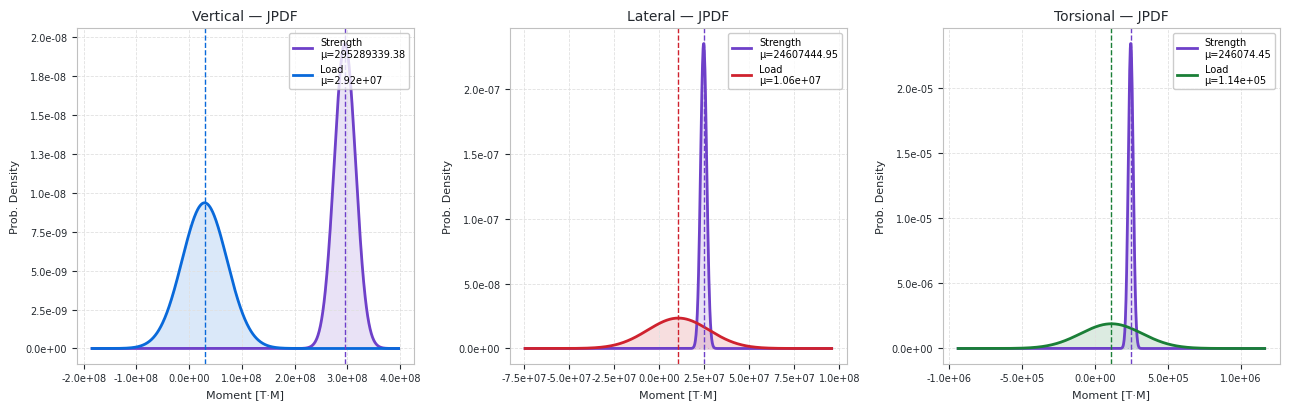

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
fig.patch.set_facecolor(BG)

config = [
    ('Vertical',  mu_Sv, std_Sv, mu_vm, std_vm, COLORS['vert']),
    ('Lateral',   mu_Sl, std_Sl, mu_lm, std_lm, COLORS['lat']),
    ('Torsional', mu_St, std_St, mu_tm, std_tm, COLORS['tors']),
]

for ax, (name, mu_S, std_S, mu_L, std_L, color) in zip(axes, config):
    ax.set_facecolor(BG)
    lo = min(mu_S - 5*std_S, mu_L - 5*std_L)
    hi = max(mu_S + 5*std_S, mu_L + 5*std_L)
    x  = np.linspace(lo, hi, 1000)

    # Strength (S)
    pdf_S = norm.pdf(x, mu_S, std_S)
    ax.plot(x, pdf_S, color='#6e40c9', lw=2, label=f'Strength\nμ={mu_S:.2f}')
    ax.fill_between(x, pdf_S, color='#6e40c9', alpha=0.15)

    # Load (L)
    pdf_L = norm.pdf(x, mu_L, std_L)
    ax.plot(x, pdf_L, color=color, lw=2, label=f'Load\nμ={mu_L:.2e}')
    ax.fill_between(x, pdf_L, color=color, alpha=0.15)

    ax.axvline(mu_S, color='#6e40c9', ls='--', lw=1)
    ax.axvline(mu_L, color=color, ls='--', lw=1)
    ax.grid(True,ls='--',lw=0.6,color=GRID)
    for s in ax.spines.values(): s.set_color(SPINE)
    ax.tick_params(colors=TEXT,labelsize=7)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{y:.1e}'))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: f'{v:.1e}'))
    ax.set_title(f'{name} — JPDF',fontsize=10,color=TEXT)
    ax.set_xlabel('Moment [T·M]',fontsize=8,color=TEXT)
    ax.set_ylabel('Prob. Density',fontsize=8,color=TEXT)
    ax.legend(fontsize=7,edgecolor=SPINE,facecolor=BG,loc='upper right')

plt.tight_layout(); plt.show()